# Accuracy Is Not Robustness
### Realistic Evasion Attacks on Phishing Website Detectors

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Jatinkumar78/Accuracy-Is-Not-Robustness/blob/main/notebooks/accuracy_is_not_robustness.ipynb)
[![Python 3.10+](https://img.shields.io/badge/python-3.10%2B-blue.svg)](https://www.python.org/)
[![License: MIT](https://img.shields.io/badge/license-MIT-green.svg)](../LICENSE)

---

## What this notebook does

Phishing detectors are routinely reported at 97–99% accuracy. This notebook tests
whether that number survives contact with an adversary.

Six detectors are trained on two public datasets, then attacked by two adversaries
that are only permitted to edit the parts of a URL and page **that an attacker
actually authors**. The result is a measurement nobody reports: how much detection
is left once the attacker starts editing.

### The five stages

| Stage | What happens | Why it matters |
|:--|:--|:--|
| **1. Data** | Load two datasets, split every feature into attacker-controllable or not | The split is the whole experiment |
| **2. Models** | Train 4 tree ensembles + 2 deep networks + a surrogate | Covers what people actually deploy |
| **3. Attack** | Transfer PGD and a hard-label Boundary attack | Two attackers so no result depends on one |
| **4. Analysis** | Robustness curves, evasion cost, feature reliance | Explains *why* models differ |
| **5. Defence** | Adversarial training, re-attacked by an unseen attacker | Separates real hardening from memorisation |

### What you get at the end

- Trained models saved to disk and downloadable (`.joblib`)
- Every measured number written to `results.json`
- Publication-quality figures as PNG and PDF

---

## Runtime

Roughly **12–20 minutes** on a free Colab CPU runtime. No GPU required.
The slowest steps are the Boundary attack on the larger dataset and the 1D-CNN.

> **Nothing to upload.** Dataset A is embedded in this notebook; Dataset B downloads
> automatically. Press *Runtime → Run all* and walk away.

---
## 1. Environment setup

Colab ships most of what is needed. Only CatBoost is missing.

Each install is wrapped so a re-run is cheap, and the fallback to
`--break-system-packages` exists because some managed Python environments refuse a
plain `pip install` into the system site-packages.

In [1]:
import importlib, subprocess, sys

def ensure(module_name: str, pip_name: str | None = None) -> bool:
    """Import a module, installing it first if it is not already present.

    Two install attempts are made. Newer Python environments mark the system
    site-packages as externally managed and reject a plain install, so the second
    attempt passes --break-system-packages. Returning a bool rather than raising
    lets the caller report every missing package at once instead of dying on the
    first one.
    """
    try:
        importlib.import_module(module_name)
        print(f"  {module_name:<14} already available")
        return True
    except ImportError:
        pass

    print(f"  {module_name:<14} installing ...")
    for extra_args in ([], ["--break-system-packages"]):
        cmd = [sys.executable, "-m", "pip", "install", "-q", pip_name or module_name] + extra_args
        try:
            subprocess.run(cmd, check=True, capture_output=True)
            importlib.invalidate_caches()
            importlib.import_module(module_name)
            print(f"  {module_name:<14} installed")
            return True
        except Exception:
            continue
    print(f"  {module_name:<14} COULD NOT INSTALL")
    return False

print("Checking dependencies ...")
ok = all([
    ensure("numpy"),                      # array maths; every attack is written in it
    ensure("pandas"),                     # only used to read the two CSV files
    ensure("sklearn", "scikit-learn"),    # splitting, scaling, Random Forest, MLP, metrics
    ensure("matplotlib"),                 # figures
    ensure("joblib"),                     # saving trained models to disk
    ensure("xgboost"),                    # gradient-boosted trees, one of the four detectors
    ensure("lightgbm"),                   # gradient-boosted trees, and the model we harden
    ensure("catboost"),                   # gradient-boosted trees with ordered boosting
])
print("\nAll dependencies satisfied." if ok else
      "\nSomething failed. On Colab: Runtime > Restart session, then re-run this cell.")

Checking dependencies ...
  numpy          already available
  pandas         already available
  sklearn        already available
  matplotlib     already available
  joblib         already available
  xgboost        already available
  lightgbm       already available
  catboost       installing ...
  catboost       installed

All dependencies satisfied.


### Imports, and why each library is here

Rather than a wall of imports, each one is grouped with the job it does. The
attacks themselves are deliberately written in plain NumPy so that every step is
inspectable, with no attack library hiding the constraint logic.

In [2]:
# --- core numerics -----------------------------------------------------------
import numpy as np              # all attack maths: perturbations, norms, projections
import pandas as pd             # reading the two CSVs, nothing more

# --- plumbing ----------------------------------------------------------------
import io, gzip, base64         # decoding the embedded dataset without touching disk
import json, time, hashlib      # results export, timing, dataset integrity check
import urllib.request           # downloading Dataset B
import warnings, os
warnings.filterwarnings("ignore")   # LightGBM and sklearn are chatty; the noise hides real output

# --- modelling ---------------------------------------------------------------
from sklearn.model_selection import train_test_split   # stratified 80/20 split
from sklearn.preprocessing import StandardScaler       # attacks need comparable feature scales
from sklearn.ensemble import RandomForestClassifier    # bagged trees, detector 1
from sklearn.neural_network import MLPClassifier       # deep feedforward net, detector 5
from sklearn.inspection import permutation_importance  # unbiased check on tree importances
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
from xgboost import XGBClassifier                      # detector 2
from lightgbm import LGBMClassifier                    # detector 3, and the one we defend
from catboost import CatBoostClassifier                # detector 4

# --- persistence and plotting ------------------------------------------------
import joblib                   # sklearn-compatible model serialisation
import matplotlib
import matplotlib.pyplot as plt

# A single seed drives the split, model initialisation and attack randomness, so
# every number below reproduces exactly on a re-run.
SEED = 42
np.random.seed(SEED)

# Experiment settings. These are the values used in the paper.
# For a fast demo pass, set N_ATTACK = 150; the conclusions are unchanged.
N_ATTACK       = 400   # phishing pages handed to the Boundary attack
BOUNDARY_STEPS = 100   # refinement iterations
PGD_STEPS      = 30    # projected-gradient steps in the transfer attack

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

os.makedirs("models", exist_ok=True)   # trained detectors are written here
os.makedirs("figures", exist_ok=True)  # figures are written here

print(f"Ready. numpy {np.__version__} | pandas {pd.__version__} | seed {SEED}")

Ready. numpy 2.0.2 | pandas 2.2.2 | seed 42


---
## 2. Loading the data

**Dataset A** (Tan, 2018) sits behind a Mendeley download page, which makes automated
fetching unreliable. It is therefore embedded in this notebook as a gzip-compressed,
base64-encoded string and decoded straight into memory. An MD5 checksum is printed so
you can confirm the bytes match the original file.

**Dataset B** (Vrbančič et al., 2020) is on GitHub and downloads directly.

In [3]:
# Dataset A, gzipped and base64-encoded. Embedding it removes the single most
# common cause of a broken notebook: a missing data file.
DATASET_A_B64 = "..."
print(f"Embedded payload: {len(DATASET_A_B64):,} characters")

Embedded payload: 272,060 characters


In [4]:
# Decode -> decompress -> parse. Nothing is written to disk.
raw_bytes = gzip.decompress(base64.b64decode(DATASET_A_B64))
print(f"Decompressed  : {len(raw_bytes):,} bytes")
print(f"MD5 checksum  : {hashlib.md5(raw_bytes).hexdigest()}")
print(f"Expected      : 971f9ccd17276801538a7573d4caae66")

df_a = pd.read_csv(io.BytesIO(raw_bytes))
print(f"\nDataset A: {df_a.shape[0]:,} rows x {df_a.shape[1]} columns")
df_a.head(3)

Decompressed  : 1,416,307 bytes
MD5 checksum  : 971f9ccd17276801538a7573d4caae66
Expected      : 971f9ccd17276801538a7573d4caae66

Dataset A: 10,000 rows x 50 columns


,id,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,...,IframeOrFrame,MissingTitle,ImagesOnlyInForm,SubdomainLevelRT,UrlLengthRT,PctExtResourceUrlsRT,AbnormalExtFormActionR,ExtMetaScriptLinkRT,PctExtNullSelfRedirectHyperlinksRT,CLASS_LABEL
0,1,3,1,5,72,0,0,0,0,0,...,0,0,1,1,0,1,1,-1,1,1
1,2,3,1,3,144,0,0,0,0,2,...,0,0,0,1,-1,1,1,1,1,1
2,3,3,1,2,58,0,0,0,0,0,...,0,0,0,1,0,-1,1,-1,0,1


In [5]:
DATASET_B_URL = ("https://raw.githubusercontent.com/GregaVrbancic/"
                 "Phishing-Dataset/master/dataset_small.csv")

def fetch_csv(url: str, attempts: int = 3) -> pd.DataFrame:
    """Download a CSV into a DataFrame, retrying on transient network failures.

    Colab occasionally drops the first request of a session, so a bare urlopen
    would make the notebook look broken when it is not.
    """
    last_error = None
    for attempt in range(1, attempts + 1):
        try:
            with urllib.request.urlopen(url, timeout=60) as response:
                payload = response.read()
            print(f"Downloaded {len(payload):,} bytes on attempt {attempt}")
            return pd.read_csv(io.BytesIO(payload))
        except Exception as err:
            last_error = err
            print(f"  attempt {attempt} failed ({err}); retrying ...")
            time.sleep(3)
    raise RuntimeError(f"Could not download Dataset B: {last_error}")

df_b = fetch_csv(DATASET_B_URL)

# Exact duplicate rows would leak identical samples across the train/test split
# and inflate every score, so they are removed before anything else happens.
rows_before = len(df_b)
df_b = df_b.drop_duplicates().reset_index(drop=True)
print(f"\nDataset B: {rows_before:,} rows -> {len(df_b):,} after removing "
      f"{rows_before - len(df_b):,} exact duplicates")
print(f"Phishing proportion: {df_b['phishing'].mean():.3f}")

Downloaded 16,028,060 bytes on attempt 1

Dataset B: 58,645 rows -> 57,405 after removing 1,240 exact duplicates
Phishing proportion: 0.531


---
## 3. The feature partition — the heart of the experiment

Every feature is placed in one of two groups.

**Mutable** features are those an attacker sets simply by registering a URL and
writing markup: how many dots are in the hostname, how long the path is, what
fraction of links point off-site. These are free for the attacker to change.

**Immutable** features reflect hosting infrastructure: domain registration age,
name-server counts, TLS certificate state. An attacker *can* change these, but only
by buying a domain earlier or provisioning different infrastructure, which costs
money and time that authoring a page does not.

**The attacks below are only ever allowed to touch the mutable group.** That single
constraint is what separates a realistic evasion attempt from a maths exercise.

In [6]:
# --- Dataset A: 19 of 48 features are attacker-authored ----------------------
MUTABLE_A = [
    "NumDots", "SubdomainLevel", "PathLevel", "UrlLength", "NumDash",
    "NumDashInHostname", "NumUnderscore", "NumPercent", "NumQueryComponents",
    "NumAmpersand", "NumHash", "NumNumericChars", "HostnameLength", "PathLength",
    "QueryLength", "NumSensitiveWords", "PctExtHyperlinks", "PctExtResourceUrls",
    "PctNullSelfRedirectHyperlinks",
]
features_a = [c for c in df_a.columns if c not in ("id", "CLASS_LABEL")]
X_a = df_a[features_a].values.astype(float)
y_a = df_a["CLASS_LABEL"].values.astype(int)

# --- Dataset B: mutable = the per-segment character counts -------------------
# Anything counting characters inside the url / directory / file / params
# segments is written by whoever composed the URL.
features_b = [c for c in df_b.columns if c != "phishing"]

def is_mutable_b(column: str) -> bool:
    if column.endswith(("_url", "_directory", "_file", "_params")):
        return True
    return column in ("directory_length", "file_length", "params_length")

MUTABLE_B = [c for c in features_b if is_mutable_b(c)]
X_b = df_b[features_b].values.astype(float)
y_b = df_b["phishing"].values.astype(int)

for name, feats, mut in [("A", features_a, MUTABLE_A), ("B", features_b, MUTABLE_B)]:
    present = [f for f in mut if f in feats]
    print(f"Dataset {name}: {len(feats):3d} features "
          f"| {len(present):3d} mutable | {len(feats)-len(present):3d} immutable")

print("\nExample immutable features on Dataset B (an attacker cannot fake these):")
print("  ", [c for c in features_b if c not in MUTABLE_B][:6])

Dataset A:  48 features |  19 mutable |  29 immutable
Dataset B: 111 features |  76 mutable |  35 immutable

Example immutable features on Dataset B (an attacker cannot fake these):
   ['qty_dot_domain', 'qty_hyphen_domain', 'qty_underline_domain', 'qty_slash_domain', 'qty_questionmark_domain', 'qty_equal_domain']


---
## 4. The validity projection

An adversarial example only counts if it describes a page somebody could actually
build. A perturbation that sets "number of dots" to 2.7, or pushes URL length beyond
anything ever observed, is a curiosity rather than a security finding.

So after **every** attack step the candidate is pushed back into the space of legal
feature vectors. The projection does three things:

1. **Clip** each feature to the range seen in training
2. **Round** count features back to whole numbers
3. **Freeze** the immutable features at their original values

This is the function that makes the whole study credible.

In [7]:
def make_projection(mean, scale, lower, upper, integer_mask):
    """Build the validity projection used after every attack step.

    The models see standardised features, but the constraints are natural in raw
    units, so the projection converts back, applies the constraints, and converts
    forward again.

    Parameters
    ----------
    mean, scale : per-feature standardisation statistics from the TRAINING split
    lower, upper : per-feature min and max observed in training
    integer_mask : boolean mask marking count features that must stay whole
    """
    def project(x_std):
        raw = x_std * scale + mean                          # standardised -> raw units
        raw = np.clip(raw, lower, upper)                    # stay inside observed ranges
        raw[:, integer_mask] = np.round(raw[:, integer_mask])   # counts are integers
        return (raw - mean) / scale                         # back to standardised space
    return project

print("Validity projection defined.")

Validity projection defined.


---
## 5. The six detectors

Four tree ensembles, because they are what the phishing literature actually
recommends and what gets deployed. Two deep networks, so the findings are not an
artefact of one model family.

The **surrogate** at the end is not a detector. It exists only because tree ensembles
have no gradients, so the transfer attack needs a differentiable stand-in to
compute gradients against.

In [8]:
class CNN1D:
    """A small 1D convolutional network, written directly in NumPy.

    Included as a second deep-learning detector with a genuinely different
    inductive bias from the feedforward MLP. Convolution assumes local structure,
    which the per-segment counts in Dataset B do have.

    Written by hand rather than in PyTorch so the notebook has no heavyweight GPU
    dependency and every operation stays visible.
    """

    # Gradient steps are held constant across datasets rather than epochs, so a
    # six-times larger dataset does not silently receive six times the training.
    STEPS = 800

    def __init__(self, n_features, f1=12, f2=16, kernel=5, hidden=32, seed=0):
        rng = np.random.RandomState(seed)
        self.k = kernel
        # He initialisation, appropriate for ReLU activations
        self.W1 = rng.randn(f1, 1, kernel) * np.sqrt(2 / kernel);          self.b1 = np.zeros(f1)
        self.W2 = rng.randn(f2, f1, kernel) * np.sqrt(2 / (f1 * kernel));  self.b2 = np.zeros(f2)
        self.W3 = rng.randn(f2, hidden) * np.sqrt(2 / f2);                 self.b3 = np.zeros(hidden)
        self.W4 = rng.randn(hidden, 1) * np.sqrt(2 / hidden);              self.b4 = np.zeros(1)

    @staticmethod
    def _pad(x, k):
        return np.pad(x, ((0, 0), (0, 0), (k // 2, k // 2)))

    def _conv(self, x, W, b):
        """1D convolution via a sliding-window gather plus one tensordot."""
        n, c_in, length = x.shape
        c_out, _, k = W.shape
        padded = self._pad(x, k)
        idx = np.arange(length)[:, None] + np.arange(k)[None, :]
        windows = padded[:, :, idx]                                  # (n, c_in, L, k)
        out = np.tensordot(windows, W, axes=([1, 3], [1, 2]))        # (n, L, c_out)
        return np.transpose(out, (0, 2, 1)) + b[None, :, None]

    def forward(self, X):
        x = X[:, None, :]
        self.z1 = self._conv(x, self.W1, self.b1);        self.a1 = np.maximum(0, self.z1)
        self.z2 = self._conv(self.a1, self.W2, self.b2);  self.a2 = np.maximum(0, self.z2)
        self.pool_idx = self.a2.argmax(axis=2)
        self.pooled = self.a2.max(axis=2)                            # global max pooling
        self.z3 = self.pooled @ self.W3 + self.b3;        self.a3 = np.maximum(0, self.z3)
        self.z4 = self.a3 @ self.W4 + self.b4
        return 1 / (1 + np.exp(-np.clip(self.z4, -30, 30)))

    def fit(self, X, y, epochs=None, lr=0.03, batch=256):
        y = y.reshape(-1, 1).astype(float)
        n = len(X)
        if epochs is None:
            epochs = max(4, int(round(self.STEPS / max(1, n // batch))))
        rng = np.random.RandomState(0)
        for _ in range(epochs):
            order = rng.permutation(n)
            for i in range(0, n, batch):
                b = order[i:i + batch]; xb, yb = X[b], y[b]
                p = self.forward(xb); m = len(b)
                g4 = (p - yb) / m
                dW4 = self.a3.T @ g4;      db4 = g4.sum(0)
                g3 = (g4 @ self.W4.T) * (self.z3 > 0)
                dW3 = self.pooled.T @ g3;  db3 = g3.sum(0)
                gp = g3 @ self.W3.T
                # route the pooled gradient back to the position that won the max
                grad_a2 = np.zeros_like(self.a2)
                ni, fi = np.meshgrid(np.arange(m), np.arange(grad_a2.shape[1]), indexing="ij")
                grad_a2[ni, fi, self.pool_idx] = gp
                gz2 = grad_a2 * (self.z2 > 0)
                a1p = self._pad(self.a1, self.k)
                idx = np.arange(self.a1.shape[2])[:, None] + np.arange(self.k)[None, :]
                dW2 = np.tensordot(gz2, a1p[:, :, idx], axes=([0, 2], [0, 2]))
                db2 = gz2.sum(axis=(0, 2))
                gz1 = np.tensordot(gz2, self.W2, axes=([1], [0])).sum(axis=3)
                gz1 = gz1.transpose(0, 2, 1) * (self.z1 > 0)
                xp = self._pad(xb[:, None, :], self.k)
                dW1 = np.tensordot(gz1, xp[:, :, idx], axes=([0, 2], [0, 2]))
                db1 = gz1.sum(axis=(0, 2))
                for param, grad in ((self.W4, dW4), (self.b4, db4), (self.W3, dW3),
                                    (self.b3, db3), (self.W2, dW2), (self.b2, db2),
                                    (self.W1, dW1), (self.b1, db1)):
                    param -= lr * np.clip(grad, -1, 1)   # clipping keeps the small net stable
        return self

    def _forward_batched(self, X, batch=512):
        """Chunked inference. A full-test-set forward pass on the larger dataset
        would allocate over a gigabyte in the sliding-window tensor."""
        out = np.empty(len(X))
        for i in range(0, len(X), batch):
            out[i:i + batch] = self.forward(X[i:i + batch]).ravel()
        return out

    def predict_proba(self, X):
        p = self._forward_batched(X)
        return np.column_stack([1 - p, p])

    def predict(self, X):
        return (self._forward_batched(X) >= 0.5).astype(int)


class SurrogateMLP:
    """One-hidden-layer network used ONLY to supply gradients to the transfer attack.

    Tree ensembles are not differentiable, so the attacker trains this stand-in on
    similar data and hopes the perturbations carry across. It is never evaluated as
    a detector.
    """
    def __init__(self, d, hidden=128, seed=0):
        rng = np.random.RandomState(seed)
        self.W1 = rng.randn(d, hidden) * np.sqrt(2 / d);   self.b1 = np.zeros(hidden)
        self.W2 = rng.randn(hidden, 1) * np.sqrt(2 / hidden); self.b2 = np.zeros(1)

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1; self.a1 = np.maximum(0, self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        return 1 / (1 + np.exp(-np.clip(self.z2, -30, 30)))

    def fit(self, X, y, epochs=200, lr=0.05, batch=256):
        y = y.reshape(-1, 1).astype(float); n = len(X)
        for _ in range(epochs):
            order = np.random.permutation(n)
            for i in range(0, n, batch):
                b = order[i:i + batch]; xb, yb = X[b], y[b]
                p = self.forward(xb); g2 = (p - yb) / len(b)
                dW2 = self.a1.T @ g2; db2 = g2.sum(0)
                g1 = (g2 @ self.W2.T) * (self.z1 > 0)
                self.W2 -= lr * dW2; self.b2 -= lr * db2
                self.W1 -= lr * (xb.T @ g1); self.b1 -= lr * g1.sum(0)
        return self

    def input_gradient(self, X, y):
        """Gradient of the loss with respect to the INPUT, which is what PGD needs."""
        y = y.reshape(-1, 1).astype(float)
        p = self.forward(X); g2 = (p - y)
        g1 = (g2 @ self.W2.T) * (self.z1 > 0)
        return g1 @ self.W1.T

print("Deep models and surrogate defined.")

Deep models and surrogate defined.


In [9]:
def build_detectors(seed: int, n_features: int) -> dict:
    """The six detectors, with identical settings on both datasets.

    Hyperparameters are deliberately ordinary. The point of the study is not to
    squeeze out the last 0.1% of accuracy; it is to show that accuracy stops being
    informative once an attacker is involved.
    """
    return {
        # Bagged trees: spreads importance thinly across many weak features
        "RandomForest": RandomForestClassifier(
            n_estimators=250, max_features="sqrt", random_state=seed, n_jobs=-1),

        # Gradient boosting: concentrates importance on a few strong features
        "XGBoost": XGBClassifier(
            n_estimators=350, max_depth=6, learning_rate=0.04, subsample=0.9,
            colsample_bytree=0.8, reg_lambda=1.0, eval_metric="logloss",
            random_state=seed, n_jobs=-1),

        # Leaf-wise boosting, and the model we later harden
        "LightGBM": LGBMClassifier(
            n_estimators=400, learning_rate=0.04, num_leaves=63, subsample=0.9,
            colsample_bytree=0.8, reg_lambda=1.0, random_state=seed,
            n_jobs=-1, verbose=-1),

        # Ordered boosting, a different bias again
        "CatBoost": CatBoostClassifier(
            iterations=350, depth=6, learning_rate=0.05, l2_leaf_reg=3.0,
            random_seed=seed, verbose=0, thread_count=-1),

        # Deep feedforward network: the standard tabular deep-learning baseline
        "DeepMLP": MLPClassifier(
            hidden_layer_sizes=(256, 128, 64), activation="relu", solver="adam",
            alpha=1e-4, batch_size=256, learning_rate_init=1e-3, max_iter=120,
            early_stopping=True, n_iter_no_change=10, random_state=seed),

        # Convolutional network: a genuinely different architecture
        "CNN1D": CNN1D(n_features, seed=seed),
    }


def evaluate_clean(model, X_test, y_test) -> dict:
    """The five clean-performance metrics reported in the paper."""
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]
    return dict(
        acc=accuracy_score(y_test, predictions),
        prec=precision_score(y_test, predictions),
        rec=recall_score(y_test, predictions),
        f1=f1_score(y_test, predictions),
        auc=roc_auc_score(y_test, probabilities),
    )

print("Detector factory ready: 6 models.")

Detector factory ready: 6 models.


---
## 6. Attack 1 — transfer PGD

Projected gradient descent takes repeated small steps in the direction that
increases the surrogate's loss, then projects back into the permitted region.

The attacker never queries the real detector while building the attack. It works
entirely against its own stand-in model and hopes the perturbations carry across.

In [10]:
def make_pgd(surrogate, mutable_mask, projection, steps=PGD_STEPS):
    """Build a projected-gradient attack bound to one surrogate model.

    Each step: move along the sign of the input gradient, clip to the L-infinity
    ball of radius epsilon, hard-reset the immutable features, then project back
    onto the space of admissible pages.
    """
    def pgd(x_original, epsilon):
        x = x_original.copy()
        step_size = 2.5 * epsilon / steps          # standard PGD step heuristic
        target = np.ones(len(x_original))          # push everything toward "legitimate"
        for _ in range(steps):
            gradient = surrogate.input_gradient(x, target)
            x = x + step_size * np.sign(gradient) * mutable_mask   # mutable dims only
            x = np.clip(x, x_original - epsilon, x_original + epsilon)
            x = x * mutable_mask + x_original * (1 - mutable_mask) # freeze immutables
            x = projection(x)                                      # keep it a legal page
        return x
    return pgd

print("Transfer attack ready.")

Transfer attack ready.


---
## 7. Attack 2 — the constrained Boundary attack

The transfer attack has one weakness as evidence: if it succeeds, a sceptic can say
the surrogate happened to match the detector well; if it fails, they can say the
surrogate was poor.

So a second attacker is used that sees **nothing but the final yes/no answer**. No
gradients, no probabilities, no internals. It works in two phases:

1. **Warm start** — random search over mutable features at increasing magnitudes,
   keeping the smallest perturbation that flips the label
2. **Refinement** — walk that point back toward the original while staying on the
   legitimate side, with small sideways moves to escape ridges

Every candidate passes the validity projection, so each of the ~355 queries names a
page that could genuinely exist. The headline number is the **median L2 needed to
evade**, which is effectively the price the attacker pays.

In [11]:
def boundary_attack(model, X_original, projection, mutable_mask, seed=0,
                    steps=BOUNDARY_STEPS,
                    warm_magnitudes=(0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0),
                    warm_repeats=14):
    """Decision-based evasion using hard labels only.

    Note that `model.predict` is the ONLY thing called on the model anywhere in
    this function. That restraint is what makes the attack genuinely black-box:
    predict_proba and any internal attribute are never touched.

    Returns, per sample, whether it could be evaded at all and how large the
    perturbation had to be.
    """
    rng = np.random.RandomState(seed)
    n_samples, n_features = X_original.shape
    mutable_idx = np.where(mutable_mask > 0)[0]
    n_mutable = len(mutable_idx)

    best_distance = np.full(n_samples, np.inf)
    best_point = X_original.copy()
    evaded = np.zeros(n_samples, bool)
    queries = 0

    # Samples the model already gets wrong cost the attacker nothing.
    already_wrong = model.predict(X_original) == 0; queries += 1
    evaded |= already_wrong
    best_distance[already_wrong] = 0.0

    # --- phase 1: warm start by random search --------------------------------
    for magnitude in warm_magnitudes:
        for _ in range(warm_repeats):
            delta = np.zeros((n_samples, n_features))
            delta[:, mutable_idx] = np.sign(rng.uniform(-1, 1, (n_samples, n_mutable))) * magnitude
            candidate = projection(X_original + delta)
            flipped = model.predict(candidate) == 0; queries += 1
            distance = np.linalg.norm(candidate - X_original, axis=1)
            improved = flipped & (distance < best_distance)
            best_point[improved] = candidate[improved]
            best_distance[improved] = distance[improved]
            evaded |= flipped

    # --- phase 2: refine toward the original ---------------------------------
    step = 0.3
    for _ in range(steps):
        active = np.where(evaded)[0]
        if len(active) == 0:
            break
        current, original = best_point[active], X_original[active]

        # shrink toward the original page
        candidate = projection(current + step * (original - current))
        flipped = model.predict(candidate) == 0; queries += 1
        distance = np.linalg.norm(candidate - original, axis=1)
        improved = flipped & (distance < best_distance[active])
        best_point[active[improved]] = candidate[improved]
        best_distance[active[improved]] = distance[improved]

        # small perpendicular nudge so the search does not stall on a ridge
        direction = original - best_point[active]
        norm = np.linalg.norm(direction, axis=1, keepdims=True) + 1e-12
        unit = direction / norm
        noise = rng.randn(len(active), n_features) * mutable_mask
        noise = noise - np.sum(noise * unit, axis=1, keepdims=True) * unit
        noise /= (np.linalg.norm(noise, axis=1, keepdims=True) + 1e-12)
        candidate2 = projection(best_point[active] + noise * (0.1 * norm))
        flipped2 = model.predict(candidate2) == 0; queries += 1
        distance2 = np.linalg.norm(candidate2 - original, axis=1)
        improved2 = flipped2 & (distance2 < best_distance[active])
        best_point[active[improved2]] = candidate2[improved2]
        best_distance[active[improved2]] = distance2[improved2]

        # adapt the step size to the observed success rate
        rate = improved.mean() if len(improved) else 0
        step = float(np.clip(step * (1.05 if rate > 0.3 else 0.9), 1e-3, 0.9))

    return dict(evaded=evaded,
                l2=np.where(evaded, best_distance, np.inf),
                queries=queries)


def detection_curve(l2_distances, budgets):
    """Fraction of phishing pages still detected when the attacker's budget is tau."""
    return [float(np.mean(l2_distances > t)) for t in budgets]

print("Boundary attack ready.")

Boundary attack ready.


---
## 8. The full pipeline

One function runs everything for a dataset: split, standardise, train, evaluate
clean, attack twice, then build and test the defence.

**One detail worth flagging:** only the phishing class is attacked. A false negative
is the security-critical error — a phishing page that slips through does real damage,
whereas a legitimate page flagged as phishing is an annoyance. So "detection rate"
below always means *recall on phishing under attack*.

In [12]:
EPSILONS = [0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0]
TAUS     = [0.05, 0.1, 0.15, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5, 2.0]

def run_pipeline(X, y, feature_names, mutable_names, dataset_tag,
                 seed=SEED, n_attack=N_ATTACK, save_models=True, verbose=True):
    """Train, attack and defend on one dataset. Returns every measured number."""
    started = time.time()

    # --- split and standardise (statistics from TRAINING data only) ----------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y)
    scaler = StandardScaler().fit(X_train)
    X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

    # --- everything the validity projection needs ----------------------------
    integer_mask = np.array([np.allclose(X[:, j], np.round(X[:, j]))
                             for j in range(len(feature_names))])
    mutable_mask = np.zeros(len(feature_names))
    mutable_idx = [feature_names.index(f) for f in mutable_names if f in feature_names]
    mutable_mask[mutable_idx] = 1.0
    projection = make_projection(scaler.mean_, scaler.scale_,
                                 X_train.min(0), X_train.max(0), integer_mask)

    # --- train the six detectors --------------------------------------------
    detectors, clean_scores = {}, {}
    for name, model in build_detectors(seed, len(feature_names)).items():
        t = time.time()
        model.fit(X_train_s, y_train)
        detectors[name] = model
        clean_scores[name] = evaluate_clean(model, X_test_s, y_test)
        if verbose:
            print(f"   {name:<13} acc {clean_scores[name]['acc']:.4f}  ({time.time()-t:.0f}s)")

    # --- persist the trained models and the scaler --------------------------
    if save_models:
        for name, model in detectors.items():
            joblib.dump(model, f"models/{dataset_tag}_{name}.joblib")
        joblib.dump(scaler, f"models/{dataset_tag}_scaler.joblib")
        if verbose:
            print(f"   saved {len(detectors)+1} artefacts to models/")

    # --- surrogate and transfer attack --------------------------------------
    surrogate = SurrogateMLP(len(feature_names), seed=seed).fit(X_train_s, y_train)
    pgd = make_pgd(surrogate, mutable_mask, projection)

    phishing = y_test == 1
    X_phish, y_phish = X_test_s[phishing], y_test[phishing]

    transfer = {name: [] for name in detectors}
    for eps in EPSILONS:
        X_adv = X_phish if eps == 0 else pgd(X_phish, eps)
        for name, model in detectors.items():
            transfer[name].append(float(accuracy_score(y_phish, model.predict(X_adv))))

    results = dict(dataset=dataset_tag, seed=int(seed),
                   n_train=int(len(X_train)), n_test=int(len(X_test)),
                   n_features=len(feature_names), n_mutable=len(mutable_idx),
                   clean=clean_scores, eps=EPSILONS, transfer=transfer, taus=TAUS)

    # --- decision-based attack ----------------------------------------------
    X_attack = X_phish[:n_attack]
    boundary = {}
    for name, model in detectors.items():
        outcome = boundary_attack(model, X_attack, projection, mutable_mask,
                                  seed=seed, steps=BOUNDARY_STEPS)
        finite = np.isfinite(outcome["l2"])
        boundary[name] = dict(
            evadable=float(outcome["evaded"].mean()),
            med_l2=float(np.median(outcome["l2"][finite])) if finite.any() else None,
            robust=detection_curve(outcome["l2"], TAUS),
            queries=int(outcome["queries"]))
        if verbose:
            print(f"   boundary {name:<13} evadable {boundary[name]['evadable']:.3f}"
                  f"  median L2 {boundary[name]['med_l2']:.2f}")
    results["boundary"] = boundary

    # --- adversarial training, then re-attack with the UNSEEN attacker ------
    X_phish_train = X_train_s[y_train == 1]
    X_adv_train = np.vstack([pgd(X_phish_train, e)
                             for e in (0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5)])
    X_augmented = np.vstack([X_train_s, X_adv_train])
    y_augmented = np.concatenate([y_train, np.ones(len(X_adv_train), int)])

    defended = LGBMClassifier(n_estimators=400, learning_rate=0.04, num_leaves=63,
                              subsample=0.9, colsample_bytree=0.8, reg_lambda=1.0,
                              random_state=seed, n_jobs=-1, verbose=-1)
    defended.fit(X_augmented, y_augmented)
    if save_models:
        joblib.dump(defended, f"models/{dataset_tag}_LightGBM_defended.joblib")

    defended_transfer = [float(accuracy_score(y_phish, defended.predict(
        X_phish if e == 0 else pgd(X_phish, e)))) for e in EPSILONS]
    defended_boundary = boundary_attack(defended, X_attack, projection, mutable_mask,
                                        seed=seed, steps=BOUNDARY_STEPS)
    finite = np.isfinite(defended_boundary["l2"])
    results["defense"] = dict(
        clean=evaluate_clean(defended, X_test_s, y_test),
        undefended=transfer["LightGBM"],
        defended=defended_transfer,
        boundary_med_l2=float(np.median(defended_boundary["l2"][finite])))

    results["seconds"] = round(time.time() - started, 1)
    return results

print("Pipeline ready.")

Pipeline ready.


---
## 9. Run both datasets

Dataset A takes roughly two minutes, Dataset B roughly ten. Watch the clean
accuracies as they print: the tree ensembles all land around 98.5% on Dataset A,
which is exactly the "looks solved" picture the rest of this notebook takes apart.

In [13]:
print("=" * 62)
print("DATASET A  (Tan, 2018)")
print("=" * 62)
results_a = run_pipeline(X_a, y_a, features_a, MUTABLE_A, "datasetA")
print(f"\nCompleted in {results_a['seconds']}s")

DATASET A  (Tan, 2018)
   RandomForest  acc 0.9850  (2s)
   XGBoost       acc 0.9875  (6s)
   LightGBM      acc 0.9855  (5s)
   CatBoost      acc 0.9865  (4s)
   DeepMLP       acc 0.9740  (16s)
   CNN1D         acc 0.9045  (25s)
   saved 7 artefacts to models/
   boundary RandomForest  evadable 0.948  median L2 2.64
   boundary XGBoost       evadable 0.990  median L2 1.85
   boundary LightGBM      evadable 0.990  median L2 2.03
   boundary CatBoost      evadable 0.950  median L2 1.58
   boundary DeepMLP       evadable 0.980  median L2 1.85
   boundary CNN1D         evadable 0.843  median L2 2.10

Completed in 121.6s


In [14]:
print("=" * 62)
print("DATASET B  (Vrbancic et al., 2020)")
print("=" * 62)
results_b = run_pipeline(X_b, y_b, features_b, MUTABLE_B, "datasetB")
print(f"\nCompleted in {results_b['seconds']}s")

DATASET B  (Vrbancic et al., 2020)
   RandomForest  acc 0.9571  (14s)
   XGBoost       acc 0.9498  (6s)
   LightGBM      acc 0.9580  (5s)
   CatBoost      acc 0.9455  (9s)
   DeepMLP       acc 0.9487  (48s)
   CNN1D         acc 0.8164  (64s)
   saved 7 artefacts to models/
   boundary RandomForest  evadable 0.578  median L2 5.86
   boundary XGBoost       evadable 0.900  median L2 5.85
   boundary LightGBM      evadable 0.807  median L2 5.71
   boundary CatBoost      evadable 0.812  median L2 5.96
   boundary DeepMLP       evadable 0.818  median L2 4.38
   boundary CNN1D         evadable 1.000  median L2 2.78

Completed in 343.0s


---
## 10. Result 1 — on clean data every model looks fine

This is the "problem is solved" view, and it is the setup for everything that follows.
Notice how tightly packed the tree ensembles are: the gaps between them are smaller
than you would get by changing the random seed.

In [15]:
MODELS = ["RandomForest", "XGBoost", "LightGBM", "CatBoost", "DeepMLP", "CNN1D"]

def clean_table(results):
    rows = [{"Model": m,
             "Accuracy": round(results["clean"][m]["acc"] * 100, 2),
             "Precision": round(results["clean"][m]["prec"] * 100, 2),
             "Recall": round(results["clean"][m]["rec"] * 100, 2),
             "F1": round(results["clean"][m]["f1"] * 100, 2),
             "ROC-AUC": round(results["clean"][m]["auc"] * 100, 2)} for m in MODELS]
    return pd.DataFrame(rows)

print("Dataset A — clean test performance (%)")
display(clean_table(results_a))
print("\nDataset B — clean test performance (%)")
display(clean_table(results_b))

Dataset A — clean test performance (%)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,RandomForest,98.50,98.79,98.2,98.50,99.89
1,XGBoost,98.75,98.60,98.9,98.75,99.88
2,LightGBM,98.55,98.60,98.5,98.55,99.88
3,CatBoost,98.65,98.41,98.9,98.65,99.85
4,DeepMLP,97.40,97.59,97.2,97.39,99.67
5,CNN1D,90.45,88.71,92.7,90.66,95.96



Dataset B — clean test performance (%)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,RandomForest,95.71,95.50,96.47,95.99,99.16
1,XGBoost,94.98,95.25,95.31,95.28,99.02
2,LightGBM,95.80,96.11,95.98,96.05,99.22
3,CatBoost,94.55,94.68,95.08,94.88,98.88
4,DeepMLP,94.87,95.96,94.31,95.13,98.63
5,CNN1D,81.64,87.11,76.80,81.63,91.34


---
## 11. Result 2 — let the attacker edit, and the datasets split apart

Same six models, same code, same attacks. The only thing that changed is which
features the dataset contains.

In [16]:
def transfer_table(results, tag):
    rows = []
    for m in MODELS:
        row = {"Dataset": tag, "Model": m}
        row.update({f"eps={e}": round(v * 100, 1)
                    for e, v in zip(results["eps"], results["transfer"][m])})
        rows.append(row)
    return pd.DataFrame(rows)

print("Phishing detection rate (%) under the transfer attack")
display(pd.concat([transfer_table(results_a, "A"), transfer_table(results_b, "B")],
                  ignore_index=True))

Phishing detection rate (%) under the transfer attack


,Dataset,Model,eps=0,eps=0.05,eps=0.1,eps=0.2,eps=0.3,eps=0.5,eps=0.75,eps=1.0
0,A,RandomForest,98.2,68.4,67.9,66.8,66.8,66.9,66.6,66.5
1,A,XGBoost,98.9,69.3,69.2,69.6,69.3,71.5,69.5,69.5
2,A,LightGBM,98.5,69.3,69.1,69.5,69.1,70.4,69.0,67.8
3,A,CatBoost,98.9,66.3,66.2,65.9,66.9,68.1,67.3,67.4
4,A,DeepMLP,97.2,96.6,96.0,91.6,85.2,79.4,71.0,66.2
5,A,CNN1D,92.7,92.3,92.3,92.0,91.4,90.0,79.9,74.8
6,B,RandomForest,96.5,96.5,96.5,95.6,93.5,90.2,89.0,88.2
7,B,XGBoost,95.3,95.3,95.3,93.8,88.7,83.1,77.0,73.1
8,B,LightGBM,96.0,96.0,96.0,94.0,89.8,83.7,78.4,75.6
9,B,CatBoost,95.1,95.1,95.1,93.7,89.5,83.2,79.5,77.4


In [17]:
def boundary_table(results, tag):
    taus = results["taus"]
    i02, i05, i20 = taus.index(0.2), taus.index(0.5), taus.index(2.0)
    return pd.DataFrame([{
        "Dataset": tag, "Model": m,
        "Evadable (%)": round(results["boundary"][m]["evadable"] * 100, 1),
        "Median L2": round(results["boundary"][m]["med_l2"], 2),
        "Det@0.2 (%)": round(results["boundary"][m]["robust"][i02] * 100, 1),
        "Det@0.5 (%)": round(results["boundary"][m]["robust"][i05] * 100, 1),
        "Det@2.0 (%)": round(results["boundary"][m]["robust"][i20] * 100, 1),
    } for m in MODELS])

print("Constrained decision-based Boundary attack")
print("(higher median L2 = the attacker must change more of the page)")
display(pd.concat([boundary_table(results_a, "A"), boundary_table(results_b, "B")],
                  ignore_index=True))

Constrained decision-based Boundary attack
(higher median L2 = the attacker must change more of the page)


,Dataset,Model,Evadable (%),Median L2,Det@0.2 (%),Det@0.5 (%),Det@2.0 (%)
0,A,RandomForest,94.8,2.64,67.2,65.5,58.8
1,A,XGBoost,99.0,1.85,66.2,64.8,47.8
2,A,LightGBM,99.0,2.03,67.8,66.5,50.7
3,A,CatBoost,95.0,1.58,64.2,63.7,44.0
4,A,DeepMLP,98.0,1.85,96.5,88.8,45.2
5,A,CNN1D,84.2,2.10,90.2,87.5,60.2
6,B,RandomForest,57.8,5.86,94.5,92.8,87.8
7,B,XGBoost,90.0,5.85,93.5,91.0,80.0
8,B,LightGBM,80.8,5.71,93.8,92.0,81.2
9,B,CatBoost,81.2,5.96,92.8,90.5,86.0


---
## 12. Result 3 — why the two datasets differ

The explanation is a single measurable quantity: **how much of the model's decision
sits in features the attacker controls?**

Two estimates are computed. Impurity-based importance comes free with tree models but
is known to favour high-cardinality features. Permutation importance is slower but
harder to argue with, so it is reported as the conservative check.

In [18]:
def mutable_share(model, feature_names, mutable_names):
    """Share of total feature importance sitting on attacker-controlled features."""
    importance = np.asarray(model.feature_importances_, dtype=float)
    importance = importance / (importance.sum() + 1e-12)
    idx = [feature_names.index(f) for f in mutable_names if f in feature_names]
    return float(importance[idx].sum())


def reliance_analysis(X, y, feature_names, mutable_names, tag):
    """Impurity and permutation importance on plain, unregularised models.

    Subsampling and regularisation shuffle importance between correlated features,
    which blurs the reading, so simpler models are used here than for detection.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y)
    scaler = StandardScaler().fit(X_train)
    X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)
    idx = [feature_names.index(f) for f in mutable_names if f in feature_names]

    out = {}
    for name, model in [
        ("RandomForest", RandomForestClassifier(n_estimators=250, random_state=SEED, n_jobs=-1)),
        ("LightGBM", LGBMClassifier(n_estimators=400, learning_rate=0.04, num_leaves=63,
                                    random_state=SEED, n_jobs=-1, verbose=-1)),
    ]:
        model.fit(X_train_s, y_train)
        impurity = mutable_share(model, feature_names, mutable_names)

        # permutation importance: shuffle one feature, measure the accuracy drop
        subset = min(3000, len(X_test_s))
        perm = permutation_importance(model, X_test_s[:subset], y_test[:subset],
                                      n_repeats=3, random_state=SEED, scoring="accuracy")
        gains = np.clip(perm.importances_mean, 0, None)
        permutation = float(gains[idx].sum() / (gains.sum() + 1e-12))

        out[name] = {"impurity": impurity, "permutation": permutation}
        print(f"   {tag} {name:<13} impurity {impurity:.3f}   permutation {permutation:.3f}")
    return out

print("Computing feature reliance (this refits two models per dataset)\n")
reliance_a = reliance_analysis(X_a, y_a, features_a, MUTABLE_A, "A")
reliance_b = reliance_analysis(X_b, y_b, features_b, MUTABLE_B, "B")

Computing feature reliance (this refits two models per dataset)

   A RandomForest  impurity 0.595   permutation 0.558
   A LightGBM      impurity 0.766   permutation 0.662
   B RandomForest  impurity 0.630   permutation 0.332
   B LightGBM      impurity 0.269   permutation 0.460


---
## 13. Figures

Four panels: the transfer attack and the Boundary attack, on each dataset. Saved to
`figures/` as both PNG and PDF so they drop straight into a paper.

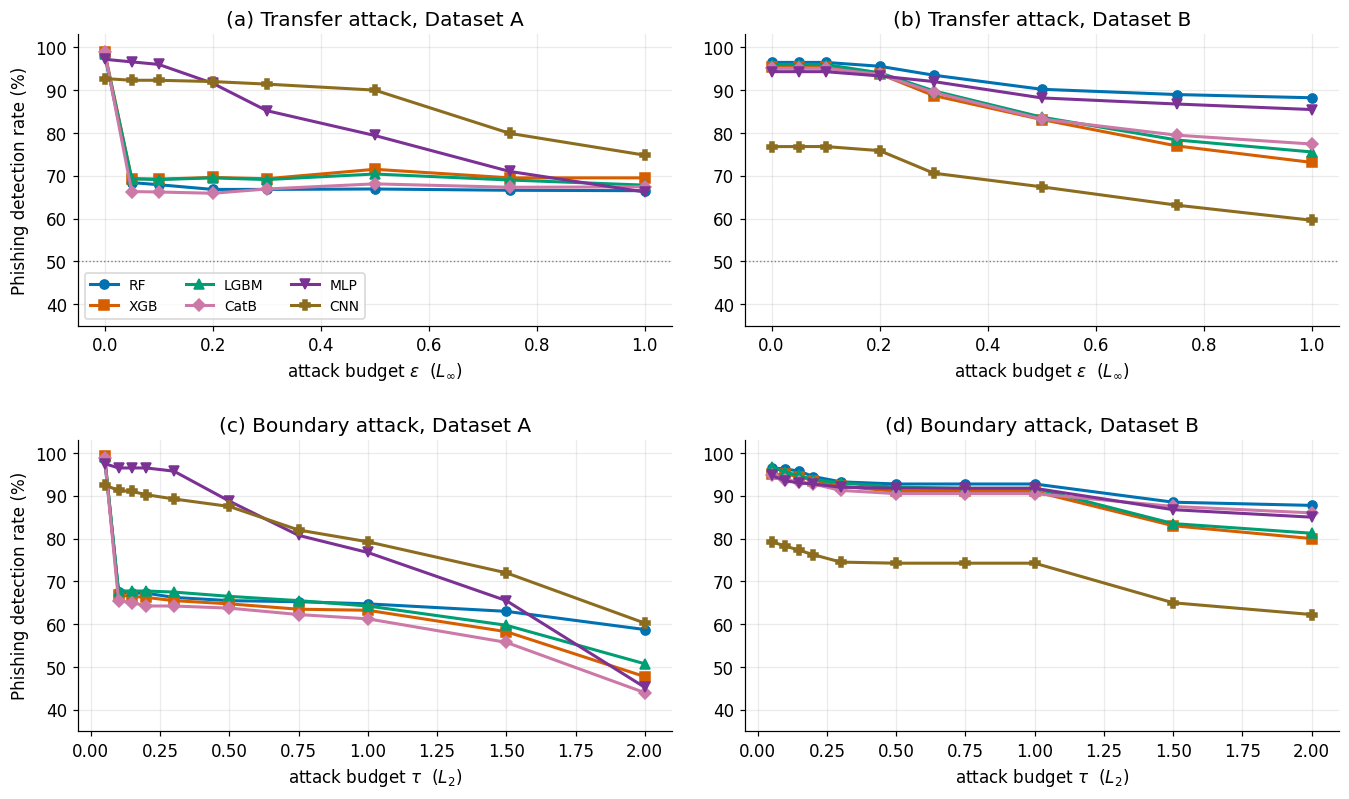

saved figures/attacks.png and .pdf


In [19]:
SHORT  = {"RandomForest": "RF", "XGBoost": "XGB", "LightGBM": "LGBM",
          "CatBoost": "CatB", "DeepMLP": "MLP", "CNN1D": "CNN"}
COLOUR = {"RandomForest": "#0072B2", "XGBoost": "#D55E00", "LightGBM": "#009E73",
          "CatBoost": "#CC79A7", "DeepMLP": "#7B3294", "CNN1D": "#8C6D1F"}
MARKER = {"RandomForest": "o", "XGBoost": "s", "LightGBM": "^",
          "CatBoost": "D", "DeepMLP": "v", "CNN1D": "P"}

fig, axs = plt.subplots(2, 2, figsize=(12.4, 7.4))
for ax, res, title in [(axs[0, 0], results_a, "(a) Transfer attack, Dataset A"),
                       (axs[0, 1], results_b, "(b) Transfer attack, Dataset B")]:
    for m in MODELS:
        ax.plot(res["eps"], [v * 100 for v in res["transfer"][m]],
                marker=MARKER[m], color=COLOUR[m], lw=2.0, ms=6, label=SHORT[m])
    ax.set_xlabel(r"attack budget $\epsilon$  ($L_\infty$)")
    ax.set_ylim(35, 103); ax.set_title(title)
    ax.axhline(50, color="grey", lw=0.9, ls=":")

for ax, res, title in [(axs[1, 0], results_a, "(c) Boundary attack, Dataset A"),
                       (axs[1, 1], results_b, "(d) Boundary attack, Dataset B")]:
    for m in MODELS:
        ax.plot(res["taus"], [v * 100 for v in res["boundary"][m]["robust"]],
                marker=MARKER[m], color=COLOUR[m], lw=2.0, ms=6, label=SHORT[m])
    ax.set_xlabel(r"attack budget $\tau$  ($L_2$)")
    ax.set_ylim(35, 103); ax.set_title(title)

axs[0, 0].set_ylabel("Phishing detection rate (%)")
axs[1, 0].set_ylabel("Phishing detection rate (%)")
axs[0, 0].legend(ncol=3, loc="lower left", fontsize=9)
fig.tight_layout(h_pad=2.0, w_pad=1.8)
fig.savefig("figures/attacks.png", dpi=180, bbox_inches="tight")
fig.savefig("figures/attacks.pdf", bbox_inches="tight")
plt.show()
print("saved figures/attacks.png and .pdf")

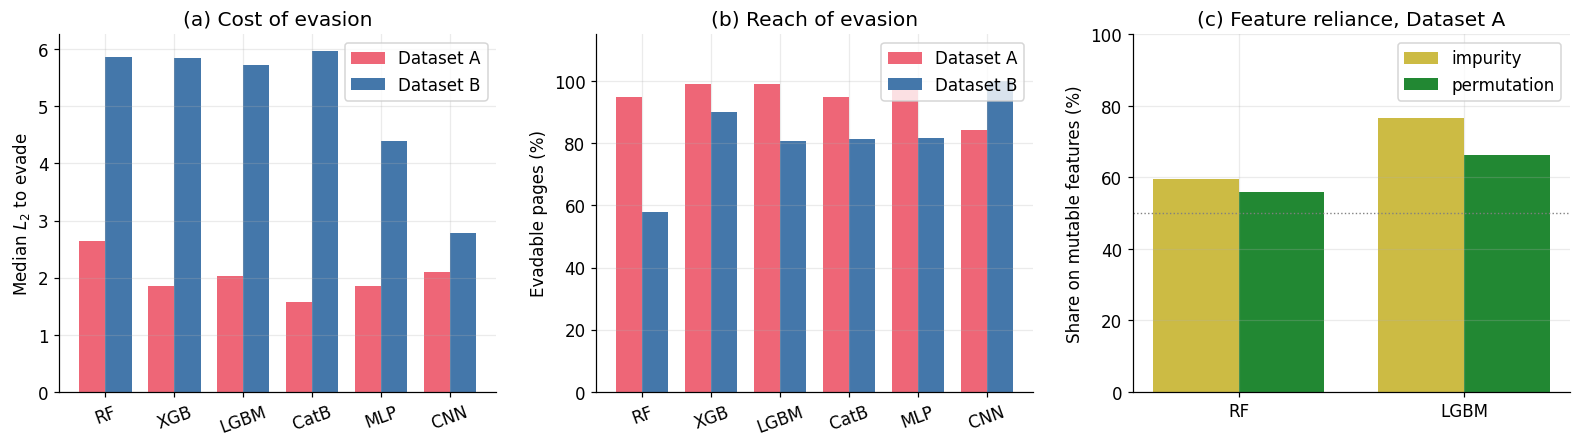

saved figures/cost_and_reliance.png and .pdf


In [20]:
fig, axs = plt.subplots(1, 3, figsize=(14.5, 4.2))
x = np.arange(len(MODELS)); width = 0.38

cost_a = [results_a["boundary"][m]["med_l2"] for m in MODELS]
cost_b = [results_b["boundary"][m]["med_l2"] for m in MODELS]
axs[0].bar(x - width/2, cost_a, width, label="Dataset A", color="#EE6677")
axs[0].bar(x + width/2, cost_b, width, label="Dataset B", color="#4477AA")
axs[0].set_xticks(x); axs[0].set_xticklabels([SHORT[m] for m in MODELS], rotation=20)
axs[0].set_ylabel("Median $L_2$ to evade"); axs[0].set_title("(a) Cost of evasion")
axs[0].legend()

reach_a = [results_a["boundary"][m]["evadable"] * 100 for m in MODELS]
reach_b = [results_b["boundary"][m]["evadable"] * 100 for m in MODELS]
axs[1].bar(x - width/2, reach_a, width, label="Dataset A", color="#EE6677")
axs[1].bar(x + width/2, reach_b, width, label="Dataset B", color="#4477AA")
axs[1].set_xticks(x); axs[1].set_xticklabels([SHORT[m] for m in MODELS], rotation=20)
axs[1].set_ylabel("Evadable pages (%)"); axs[1].set_ylim(0, 115)
axs[1].set_title("(b) Reach of evasion"); axs[1].legend()

pair = ["RandomForest", "LightGBM"]; xp = np.arange(len(pair))
imp_a = [reliance_a[m]["impurity"] * 100 for m in pair]
perm_a = [reliance_a[m]["permutation"] * 100 for m in pair]
axs[2].bar(xp - width/2, imp_a, width, label="impurity", color="#CCBB44")
axs[2].bar(xp + width/2, perm_a, width, label="permutation", color="#228833")
axs[2].set_xticks(xp); axs[2].set_xticklabels([SHORT[m] for m in pair])
axs[2].axhline(50, color="grey", lw=0.9, ls=":")
axs[2].set_ylabel("Share on mutable features (%)"); axs[2].set_ylim(0, 100)
axs[2].set_title("(c) Feature reliance, Dataset A"); axs[2].legend()

fig.tight_layout(w_pad=2.0)
fig.savefig("figures/cost_and_reliance.png", dpi=180, bbox_inches="tight")
fig.savefig("figures/cost_and_reliance.pdf", bbox_inches="tight")
plt.show()
print("saved figures/cost_and_reliance.png and .pdf")

---
## 14. Export everything

Two artefacts leave this notebook:

- **`results.json`** — every measured number, so the tables above can be rebuilt
  without re-running anything
- **`trained_models.zip`** — all 13 model files plus the fitted scalers

The saved models are ordinary joblib artefacts. Load one with
`joblib.load("models/datasetA_LightGBM.joblib")` and it behaves exactly as it did here.
Remember to load the matching scaler too, since the models expect standardised input.

In [21]:
all_results = {
    "dataset_A": results_a,
    "dataset_B": results_b,
    "reliance":  {"A": reliance_a, "B": reliance_b},
    "settings":  {"seed": SEED, "n_attack": N_ATTACK,
                  "boundary_steps": BOUNDARY_STEPS, "pgd_steps": PGD_STEPS},
}
with open("results.json", "w") as fh:
    json.dump(all_results, fh, indent=2)

size_kb = os.path.getsize("results.json") / 1024
print(f"results.json written ({size_kb:.0f} KB)")

saved = sorted(os.listdir("models"))
print(f"\n{len(saved)} model artefacts in models/:")
for name in saved:
    mb = os.path.getsize(f"models/{name}") / 1e6
    print(f"   {name:<38} {mb:6.2f} MB")

results.json written (11 KB)

16 model artefacts in models/:
   datasetA_CNN1D.joblib                   10.35 MB
   datasetA_CatBoost.joblib                 0.40 MB
   datasetA_DeepMLP.joblib                  1.30 MB
   datasetA_LightGBM.joblib                 2.76 MB
   datasetA_LightGBM_defended.joblib        2.83 MB
   datasetA_RandomForest.joblib            15.70 MB
   datasetA_XGBoost.joblib                  0.91 MB
   datasetA_scaler.joblib                   0.00 MB
   datasetB_CNN1D.joblib                   10.97 MB
   datasetB_CatBoost.joblib                 0.40 MB
   datasetB_DeepMLP.joblib                  1.69 MB
   datasetB_LightGBM.joblib                 2.81 MB
   datasetB_LightGBM_defended.joblib        2.83 MB
   datasetB_RandomForest.joblib           138.53 MB
   datasetB_XGBoost.joblib                  1.18 MB
   datasetB_scaler.joblib                   0.00 MB


In [22]:
import shutil
archive = shutil.make_archive("trained_models", "zip", "models")
print(f"{archive}  ({os.path.getsize(archive)/1e6:.1f} MB)")

# On Colab, offer the artefacts as browser downloads. Outside Colab the files are
# simply left in the working directory.
try:
    from google.colab import files
    files.download("results.json")
    files.download("trained_models.zip")
    print("\nDownloads started. Check your browser.")
except ImportError:
    print("\nNot running on Colab — files are in the working directory:")
    print("   results.json, trained_models.zip, figures/")

/content/trained_models.zip  (46.5 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Downloads started. Check your browser.


---
## 15. What the numbers say

**Clean accuracy told us nothing useful.** It did not predict how far detection would
fall, which model would hold up best, or whether the defence would help.

**Robustness came from the feature representation, not the algorithm.** Identical
models, identical attacks, opposite outcomes on the two datasets.

**There is a number you can measure before deploying.** The share of a model's
decision that sits in attacker-controlled features tracks how expensive it is to
evade. Compute it from any trained model with `mutable_share()` above.

**A defence must be tested against an attack it has not seen.** Adversarial training
looked like a clean win under the attack it trained on, until the independent
Boundary attack was run.

### Practical recommendation

Audit the mutable-importance share of any candidate detector. Where it comes back
high, either add signals the attacker cannot fabricate — domain age, name servers,
TLS certificate state — or regularise the reliance away.

---

### Citation

```bibtex
@inproceedings{accuracy_not_robustness_2026,
  title     = {Accuracy Is Not Robustness: Realistic Evasion Attacks on
               Phishing Website Detectors},
  booktitle = {Proceedings of ICETCS},
  year      = {2026}
}
```

### References

- Tan, C.L. (2018). *Phishing dataset for machine learning: feature evaluation.* Mendeley Data, V1.
- Vrbančič, G., Fister, I., Podgorelec, V. (2020). *Datasets for phishing websites detection.* Data in Brief 33, 106438.
- Brendel, W., Rauber, J., Bethge, M. (2018). *Decision-based adversarial attacks.* ICLR.
- Madry, A. et al. (2018). *Towards deep learning models resistant to adversarial attacks.* ICLR.
- Papernot, N. et al. (2017). *Practical black-box attacks against machine learning.* ACM AsiaCCS.
- Pierazzi, F. et al. (2020). *Intriguing properties of adversarial ML attacks in the problem space.* IEEE S&P.
- Apruzzese, G., Conti, M., Yuan, Y. (2022). *SpacePhish.* ACSAC.
- Montaruli, B. et al. (2023). *Raze to the ground.* ACM AISec.